# IPL Statistical Analysis

## Objective

This notebook applies statistical techniques to IPL data to understand scoring patterns, variability, relationships, and outliers.

The analysis includes:

- Mean
- Median
- Mode
- Variance
- Standard Deviation
- Quartiles
- Percentiles
- Interquartile Range (IQR)
- Outlier Detection
- Correlation
- Covariance
- Distribution Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
matches = pd.read_csv("../data/processed/cleaned_matches.csv")

deliveries = pd.read_csv("../data/processed/cleaned_deliveries.csv")

In [3]:
match_runs = (
    deliveries
    .groupby("match_id")["total_runs"]
    .sum()
)

match_runs.head()

match_id
1    379
2    371
3    367
4    327
5    299
Name: total_runs, dtype: int64

# 1. Mean

### Business Question

What is the average total runs scored in an IPL match?

### Objective

Calculate the mean match score.

In [4]:
mean_runs = match_runs.mean()

print("Mean Match Score:", round(mean_runs,2))

Mean Match Score: 311.2


### Business Insight

- The mean represents the average total runs scored in an IPL match.
- It provides a baseline for comparing high- and low-scoring matches.

# 2. Median

### Business Question

What is the middle match score?

In [5]:
median_runs = match_runs.median()

print("Median Match Score:", median_runs)

Median Match Score: 314.5


### Business Insight

- The median is less affected by unusually high or low scores.
- Comparing the mean and median helps determine whether the distribution is skewed.

# 3. Mode

### Business Question

Which total match score occurs most frequently?

In [6]:
mode_runs = match_runs.mode()

print(mode_runs)

0    331
Name: total_runs, dtype: int64


### Business Insight

- The mode identifies the most common total match score in the dataset.

In [7]:
print("Highest Match Score :", match_runs.max())

print("Lowest Match Score :", match_runs.min())

Highest Match Score : 471
Lowest Match Score : 56


In [8]:
range_runs = match_runs.max() - match_runs.min()

print("Range :", range_runs)

Range : 415


# 6. Variance

### Business Question

How much do match scores vary around the average?

Var(X) = E(X^2) - [E(X)]^2

In [9]:
variance = match_runs.var()

print("Variance :", round(variance,2))

Variance : 3296.06


# 7. Standard Deviation

### Business Question

How much do match scores typically differ from the average?

z = \frac{x - \mu}{\sigma}

In [11]:
std = match_runs.std()

print("Standard Deviation :", round(std,2))

Standard Deviation : 57.41


In [12]:
print(match_runs.quantile(0.25))

print(match_runs.quantile(0.50))

print(match_runs.quantile(0.75))

279.0
314.5
349.0


In [13]:
print("10th Percentile :", match_runs.quantile(0.10))

print("90th Percentile :", match_runs.quantile(0.90))

10th Percentile : 237.0
90th Percentile : 377.5


In [14]:
Q1 = match_runs.quantile(0.25)

Q3 = match_runs.quantile(0.75)

IQR = Q3 - Q1

print("IQR :", IQR)

IQR : 70.0


In [15]:
lower = Q1 - (1.5 * IQR)

upper = Q3 + (1.5 * IQR)

outliers = match_runs[
    (match_runs < lower) |
    (match_runs > upper)
]

outliers

match_id
35       135
54       151
99       135
120      162
206      469
233      168
251      166
301       56
428      161
471      141
621      169
7937     471
11137    150
11340    107
Name: total_runs, dtype: int64

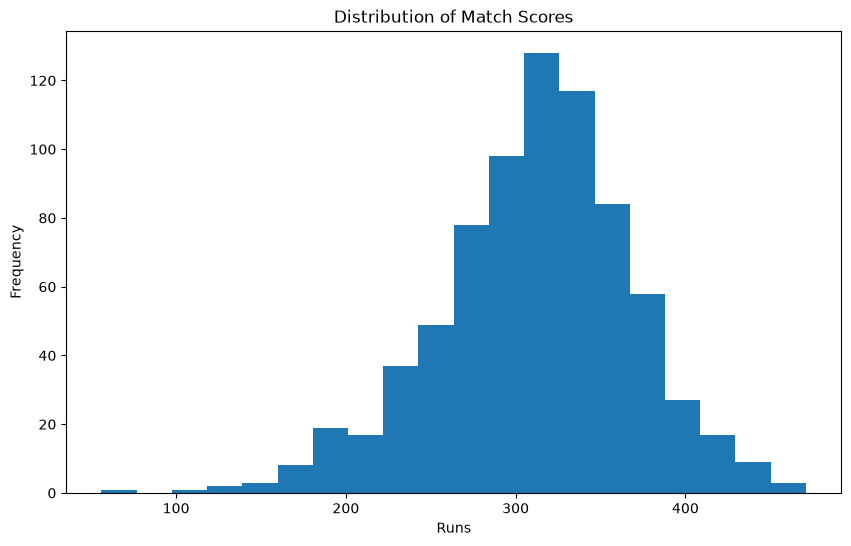

In [16]:
plt.figure(figsize=(10,6))

plt.hist(match_runs, bins=20)

plt.title("Distribution of Match Scores")

plt.xlabel("Runs")

plt.ylabel("Frequency")

plt.show()

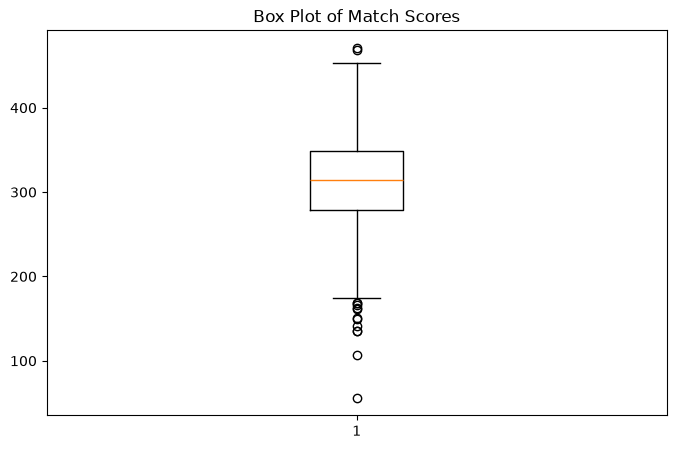

In [17]:
plt.figure(figsize=(8,5))

plt.boxplot(match_runs)

plt.title("Box Plot of Match Scores")

plt.show()

In [18]:
match_stats = (
    deliveries
    .groupby("match_id")
    .agg(
        Runs=("total_runs", "sum"),
        Extras=("extra_runs", "sum"),
        Boundaries=("batsman_runs", lambda x: ((x == 4) | (x == 6)).sum())
    )
)

match_stats.head()

,Runs,Extras,Boundaries
match_id,,,
1,379,13,49
2,371,12,47
3,367,19,52
4,327,16,38
5,299,11,36


In [19]:
match_stats.corr()

,Runs,Extras,Boundaries
Runs,1.000000,0.173750,0.917452
Extras,0.173750,1.000000,0.097223
Boundaries,0.917452,0.097223,1.000000


In [20]:
match_stats.cov()

,Runs,Extras,Boundaries
Runs,3296.060974,60.475260,524.143046
Extras,60.475260,36.754383,5.865342
Boundaries,524.143046,5.865342,99.023400
